# Unsupervised cell clustering

This notebook looks for hidden macrophage sub-populations without giving the algorithm any treatment labels. Every cell is represented only by **CD206 brightness** and **cell area**, then grouped with a simple NumPy implementation of **K-means clustering**.

The clustering is fit **separately for each donor**. That matters biologically and statistically: each donor can have its own macrophage state landscape, and cluster numbers are therefore **donor-local** rather than globally shared labels.

The workflow has two parts:
1. an interactive simulation that shows donor-specific centroids moving while K-means converges
2. a reproducible post hoc analysis that reveals which treatments are enriched in each donor-specific cluster


In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "macrophage_analysis").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks/ directory.")
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import time

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import clear_output, display

import macrophage_analysis as ma
from macrophage_analysis.analysis.morphology_tables import build_morphology_table
from macrophage_analysis.defaults import DEFAULT_SEABORN_THEME

cluster_donors = list(ma.DEFAULT_DONORS)
cluster_conditions = list(ma.DEFAULT_CONDITIONS)
cluster_antibody = "CD206"
cluster_n_tiles = (8, 8)

cluster_donors, cluster_conditions, cluster_antibody


(['D45', 'D47'],
 ['M0',
  'B68KCP2',
  'B75palmFP1',
  'M130227Ni',
  'M130429Np',
  'T12CMNepiP4',
  'T8CMNdermP6'],
 'CD206')

Run this once. The clustering notebook only extracts **CD206** so it stays focused on the two features used downstream: intensity and area.


In [2]:
cluster_results = ma.extract_single_cell_fluorescence(
    donors=cluster_donors,
    conditions=cluster_conditions,
    antibody_order=[cluster_antibody],
    n_tiles=cluster_n_tiles,
)


Analyzing CD206...
Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


100%|██████████| 64/64 [00:02<00:00, 23.88it/s]


Finished analyzing 14 donor / treatment / antibody combinations.


Build the per-cell table that K-means will use. At this stage the treatment labels are still present in the DataFrame for later interpretation, but the algorithm itself will only see the `intensity` and `area` columns and will fit each donor separately.


In [3]:
cluster_cells = build_morphology_table(
    cluster_results,
    antibody=cluster_antibody,
)

display(
    cluster_cells.groupby(["donor_label", "condition_label"], observed=True)
    .size()
    .rename("cell_count")
    .reset_index()
)


,donor_label,condition_label,cell_count
0,Donor D45,M0 (baseline),643
1,Donor D45,B68 KCP2,311
2,Donor D45,B75 palm FP1,421
3,Donor D45,M130227 Ni,318
4,Donor D45,M130429 Np,382
5,Donor D45,T12 CMN epi P4,330
6,Donor D45,T8 CMN derm P6,289
7,Donor D47,M0 (baseline),1844
8,Donor D47,B68 KCP2,1047
9,Donor D47,B75 palm FP1,1875


## Interactive donor-specific K-means simulation

Choose the number of clusters `K`, then click **Run Algorithm**. The same `K` is used for each donor, but the centroids are fit independently inside each donor. The plots are shown in the original CD206 / area space, while clustering happens on standardized features so one axis does not dominate only because of scale.


In [7]:
sns.set_theme(**DEFAULT_SEABORN_THEME)

def ordered_present_values(series):
    non_null = series.dropna()
    if isinstance(series.dtype, pd.CategoricalDtype):
        present_values = set(non_null.tolist())
        return [value for value in series.cat.categories if value in present_values]
    return list(dict.fromkeys(non_null.tolist()))


def build_feature_matrices(cells):
    feature_frame = cells[["condition", "condition_label", "donor", "donor_label", "intensity", "area"]].copy()
    display_matrix = feature_frame[["intensity", "area"]].to_numpy(dtype=float)
    feature_mean = display_matrix.mean(axis=0)
    feature_std = display_matrix.std(axis=0)
    feature_std[~np.isfinite(feature_std) | (feature_std == 0)] = 1.0
    scaled_matrix = (display_matrix - feature_mean) / feature_std
    return feature_frame, display_matrix, scaled_matrix, feature_mean, feature_std


def build_donor_feature_data(cells):
    donor_feature_data = {}
    donor_label_order = ordered_present_values(cells["donor_label"])
    for donor_label in donor_label_order:
        donor_cells = cells.loc[cells["donor_label"] == donor_label].copy()
        feature_frame, display_matrix, scaled_matrix, feature_mean, feature_std = build_feature_matrices(donor_cells)
        donor_feature_data[str(donor_label)] = {
            "feature_frame": feature_frame,
            "display_features": display_matrix,
            "scaled_features": scaled_matrix,
            "feature_mean": feature_mean,
            "feature_std": feature_std,
        }
    return donor_feature_data


def initialize_centroids(features, k, random_seed):
    if k < 1 or k > len(features):
        raise ValueError("k must be between 1 and the number of cells")
    rng = np.random.default_rng(random_seed)
    centroid_index = rng.choice(len(features), size=k, replace=False)
    return features[centroid_index].copy(), rng


def assign_clusters(features, centroids):
    distances = np.sum((features[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
    return np.argmin(distances, axis=1)


def recompute_centroids(features, assignments, centroids, rng):
    updated_centroids = centroids.copy()
    for cluster_index in range(len(centroids)):
        members = features[assignments == cluster_index]
        if len(members) == 0:
            updated_centroids[cluster_index] = features[rng.integers(len(features))]
        else:
            updated_centroids[cluster_index] = members.mean(axis=0)
    return updated_centroids


def invert_centroids(centroids, feature_mean, feature_std):
    return centroids * feature_std + feature_mean


def run_kmeans_with_history(features, k, random_seed, max_iterations=12, tolerance=1e-6):
    centroids, rng = initialize_centroids(features, k=k, random_seed=random_seed)
    history = []
    assignments = np.zeros(len(features), dtype=int)
    for iteration in range(1, max_iterations + 1):
        assignments = assign_clusters(features, centroids)
        history.append({
            "iteration": iteration,
            "phase": "assignment",
            "centroids": centroids.copy(),
            "assignments": assignments.copy(),
            "shift": np.nan,
        })
        updated_centroids = recompute_centroids(features, assignments, centroids, rng)
        total_shift = float(np.linalg.norm(updated_centroids - centroids, axis=1).sum())
        history.append({
            "iteration": iteration,
            "phase": "update",
            "centroids": updated_centroids.copy(),
            "assignments": assignments.copy(),
            "shift": total_shift,
        })
        if np.allclose(updated_centroids, centroids, atol=tolerance, rtol=0.0):
            centroids = updated_centroids
            break
        centroids = updated_centroids
    return centroids, assignments, history


def run_split_kmeans(cells, k, random_seed, max_iterations=25):
    donor_feature_data = build_donor_feature_data(cells)
    donor_runs = {}
    clustered_frames = []
    centroid_tables = []
    for donor_label, payload in donor_feature_data.items():
        final_centroids, final_assignments, history = run_kmeans_with_history(
            payload["scaled_features"],
            k=k,
            random_seed=random_seed,
            max_iterations=max_iterations,
        )
        cluster_names = [f"Cluster {cluster_index + 1}" for cluster_index in range(k)]
        clustered_cells = payload["feature_frame"].assign(
            cluster=pd.Categorical(
                [cluster_names[index] for index in final_assignments],
                categories=cluster_names,
                ordered=True,
            )
        )
        centroid_table = (
            pd.DataFrame(
                invert_centroids(final_centroids, payload["feature_mean"], payload["feature_std"]),
                columns=["cd206_intensity_centroid", "area_centroid"],
            )
            .assign(donor_label=donor_label, cluster=cluster_names)
            [["donor_label", "cluster", "cd206_intensity_centroid", "area_centroid"]]
        )
        donor_runs[donor_label] = {
            "history": history,
            "clustered_cells": clustered_cells,
            "centroid_table": centroid_table,
        }
        clustered_frames.append(clustered_cells)
        centroid_tables.append(centroid_table)
    return donor_feature_data, donor_runs, pd.concat(clustered_frames, ignore_index=True), pd.concat(centroid_tables, ignore_index=True)


def plot_kmeans_state_grid(donor_feature_data, state_by_donor, *, k):
    donor_order = list(donor_feature_data)
    palette = sns.color_palette("deep", n_colors=k)
    fig, axes = plt.subplots(
        1,
        len(donor_order),
        figsize=(7.0 * len(donor_order), 6.2),
        sharey=True,
        constrained_layout=True,
    )
    if len(donor_order) == 1:
        axes = [axes]
    count_lines = []
    for ax, donor_label in zip(axes, donor_order):
        payload = donor_feature_data[donor_label]
        state = state_by_donor[donor_label]
        centroid_display = invert_centroids(state["centroids"], payload["feature_mean"], payload["feature_std"])
        ax.scatter(
            payload["display_features"][:, 0],
            payload["display_features"][:, 1],
            c=[palette[index] for index in state["assignments"]],
            s=14,
            alpha=0.28,
            linewidth=0,
        )
        ax.scatter(
            centroid_display[:, 0],
            centroid_display[:, 1],
            c=palette,
            s=280,
            marker="X",
            edgecolor="black",
            linewidth=1.2,
        )
        for cluster_index, (x_pos, y_pos) in enumerate(centroid_display, start=1):
            ax.text(x_pos, y_pos, f"  C{cluster_index}", va="center", ha="left", fontsize=10, fontweight="bold")
        phase_label = "Assign cells" if state["phase"] == "assignment" else "Move centroids"
        shift_label = "" if np.isnan(state['shift']) else f" | shift={state['shift']:.3f}"
        ax.set_title(f"{donor_label} Iteration {state['iteration']}: {phase_label}{shift_label}", fontsize=12)
        ax.set_xlabel(f"Per-cell mean {cluster_antibody} fluorescence intensity")
        ax.set_ylabel("Cell area (pixels)" if ax is axes[0] else "")
        ax.grid(alpha=0.22)
        sns.despine(ax=ax)
        counts = np.bincount(state["assignments"], minlength=k)
        count_lines.append(
            f"{donor_label}: " + ", ".join([f"Cluster {cluster_index + 1}={count}" for cluster_index, count in enumerate(counts)])
        )
    plt.show()
    for line in count_lines:
        print(line)


cluster_donor_feature_data = build_donor_feature_data(cluster_cells)
cluster_max_k = min(8, min(len(payload["feature_frame"]) for payload in cluster_donor_feature_data.values()))
latest_kmeans_result = None

k_slider = widgets.IntSlider(value=min(3, cluster_max_k), min=2, max=cluster_max_k, step=1, description="Clusters (K)")
seed_slider = widgets.IntSlider(value=7, min=0, max=999, step=1, description="Random seed")
iteration_slider = widgets.IntSlider(value=10, min=2, max=25, step=1, description="Max iterations")
delay_slider = widgets.FloatSlider(value=0.5, min=0.1, max=1.5, step=0.1, description="Delay (s)")
run_button = widgets.Button(description="Run Algorithm", button_style="primary")
simulation_output = widgets.Output()

def run_simulation(_button):
    global latest_kmeans_result
    run_button.disabled = True
    try:
        donor_feature_data, donor_runs, clustered_cells, centroid_table = run_split_kmeans(
            cluster_cells,
            k=int(k_slider.value),
            random_seed=int(seed_slider.value),
            max_iterations=int(iteration_slider.value),
        )
        max_history_length = max(len(result["history"]) for result in donor_runs.values())
        for state_index in range(max_history_length):
            state_by_donor = {
                donor_label: result["history"][min(state_index, len(result["history"]) - 1)]
                for donor_label, result in donor_runs.items()
            }
            with simulation_output:
                clear_output(wait=True)
                plot_kmeans_state_grid(
                    donor_feature_data,
                    state_by_donor,
                    k=int(k_slider.value),
                )
            time.sleep(float(delay_slider.value))
        latest_kmeans_result = {
            "k": int(k_slider.value),
            "seed": int(seed_slider.value),
            "clustered_cells": clustered_cells,
            "centroid_table": centroid_table,
        }
    finally:
        run_button.disabled = False

run_button.on_click(run_simulation)
display(widgets.VBox([k_slider, seed_slider, iteration_slider, delay_slider, run_button, simulation_output]))


## Reveal the labels after donor-specific clustering

Once you have an idea of a useful `K` from the simulation, set the values below and run the next cells. This reruns K-means deterministically **inside each donor**, then reveals how the discovered donor-specific clusters are distributed across treatments.


In [11]:
final_cluster_k = 3
final_cluster_seed = 588
final_cluster_iterations = 10


In [12]:
(
    final_donor_feature_data,
    final_donor_runs,
    clustered_cells,
    cluster_centroid_table,
) = run_split_kmeans(
    cluster_cells,
    k=final_cluster_k,
    random_seed=final_cluster_seed,
    max_iterations=final_cluster_iterations,
)

display(cluster_centroid_table.round({"cd206_intensity_centroid": 2, "area_centroid": 1}))


,donor_label,cluster,cd206_intensity_centroid,area_centroid
0,Donor D45,Cluster 1,34.37,230.8
1,Donor D45,Cluster 2,97.84,247.2
2,Donor D45,Cluster 3,30.25,694.1
3,Donor D47,Cluster 1,18.67,279.1
4,Donor D47,Cluster 2,45.15,293.4
5,Donor D47,Cluster 3,17.40,679.0


,donor_label,condition_label,cluster,cell_count,fraction
0,Donor D45,M0 (baseline),Cluster 1,466,0.724728
1,Donor D45,M0 (baseline),Cluster 2,19,0.029549
2,Donor D45,M0 (baseline),Cluster 3,158,0.245723
3,Donor D45,B68 KCP2,Cluster 1,119,0.382637
4,Donor D45,B68 KCP2,Cluster 2,171,0.549839
5,Donor D45,B68 KCP2,Cluster 3,21,0.067524
6,Donor D45,B75 palm FP1,Cluster 1,252,0.598575
7,Donor D45,B75 palm FP1,Cluster 2,7,0.016627
8,Donor D45,B75 palm FP1,Cluster 3,162,0.384798
9,Donor D45,M130227 Ni,Cluster 1,220,0.691824


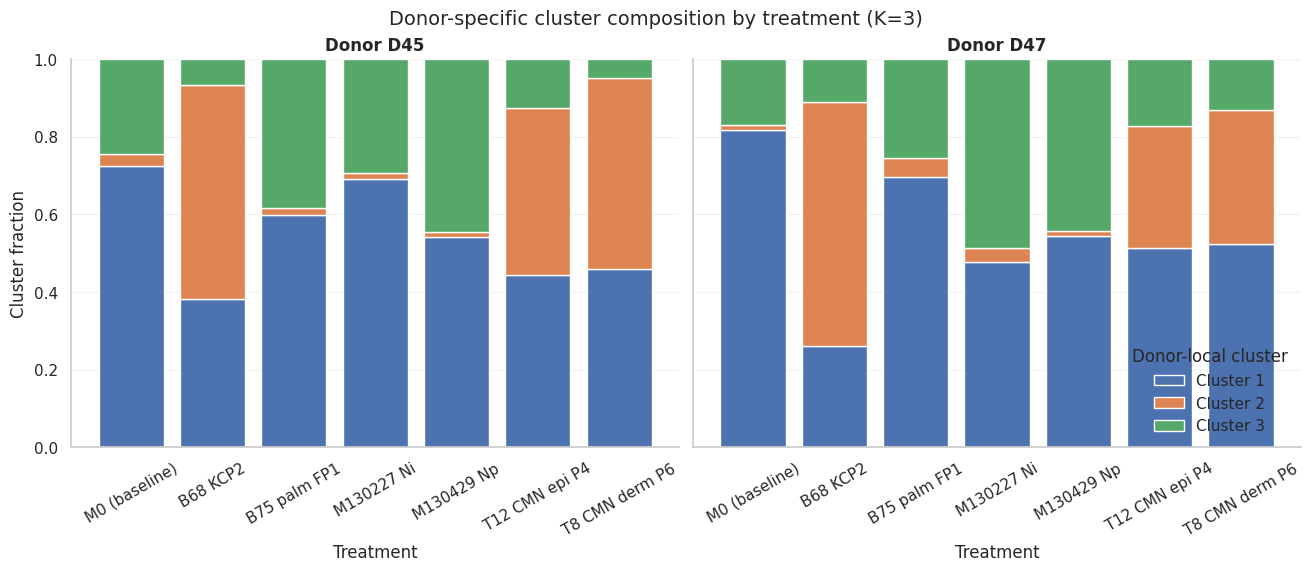

In [13]:
cluster_composition = (
    clustered_cells.groupby(["donor_label", "condition_label", "cluster"], observed=True)
    .size()
    .rename("cell_count")
    .reset_index()
)
cluster_composition["fraction"] = cluster_composition.groupby(["donor_label", "condition_label"], observed=True)["cell_count"].transform(lambda values: values / values.sum())

display(cluster_composition)

donor_label_order = ordered_present_values(clustered_cells["donor_label"])
condition_label_order = ordered_present_values(clustered_cells["condition_label"])
fig, axes = plt.subplots(
    1,
    len(donor_label_order),
    figsize=(6.5 * len(donor_label_order), 5.6),
    sharey=True,
    constrained_layout=True,
)
if len(donor_label_order) == 1:
    axes = [axes]
palette = sns.color_palette("deep", n_colors=final_cluster_k)
for ax, donor_label in zip(axes, donor_label_order):
    donor_composition = cluster_composition.loc[cluster_composition["donor_label"] == donor_label]
    donor_pivot = donor_composition.pivot(index="condition_label", columns="cluster", values="fraction").fillna(0.0)
    donor_pivot = donor_pivot.reindex(condition_label_order)
    bottom = np.zeros(len(donor_pivot), dtype=float)
    for cluster_name, color in zip([f"Cluster {cluster_index + 1}" for cluster_index in range(final_cluster_k)], palette):
        values = donor_pivot[cluster_name].to_numpy(dtype=float) if cluster_name in donor_pivot.columns else np.zeros(len(donor_pivot), dtype=float)
        ax.bar(donor_pivot.index.astype(str), values, bottom=bottom, color=color, label=cluster_name)
        bottom += values
    ax.set_title(str(donor_label), fontsize=12, fontweight="bold")
    ax.set_xlabel("Treatment")
    ax.set_ylabel("Cluster fraction" if ax is axes[0] else "")
    ax.set_ylim(0.0, 1.0)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.25)
    sns.despine(ax=ax)
legend = axes[-1].legend(frameon=False, title="Donor-local cluster")
fig.suptitle(f"Donor-specific cluster composition by treatment (K={final_cluster_k})", fontsize=14)
plt.show()
